## 1. Imports

In [1]:
# IMPORT REQUIRED LIBRARIES

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
    precision_recall_curve, average_precision_score
)

from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


## 2. Load Dataset

In [2]:
# LOAD PRE-PROCESSED DATASET

DATA_PATH = os.path.join('..', 'data', 'Processed', 'cleaned_dataset.csv')

df = pd.read_csv(DATA_PATH)

# CLEAN TARGET COLUMN
df['Attrition'] = df['Attrition'].astype(str).str.strip()

# Convert to binary
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Remove invalid rows
df = df.dropna(subset=['Attrition'])

# Split features & target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Convert boolean columns → integers
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

print("Dataset loaded successfully ✅")
print("Dataset shape:", df.shape)

Dataset loaded successfully ✅
Dataset shape: (1470, 31)


## 3. Train/Test Split

In [3]:
# TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# VERY IMPORTANT — FORCE INTEGER TYPE
y_train = y_train.astype(int)
y_test = y_test.astype(int)

print("Train/Test split completed ✅")

Train/Test split completed ✅


## 4. Load Models

In [4]:
# LOAD TRAINED MODELS

rf_model = joblib.load('../models/random_forest_tuned.joblib')
xgb_model = joblib.load('../models/xgboost_tuned.joblib')

print("Models loaded successfully ✅")

Models loaded successfully ✅


## 5. Predictions

In [5]:
# GENERATE PREDICTIONS 

def align_features(X, model):
    model_features = list(model.feature_names_in_)
    
    for col in model_features:
        if col not in X.columns:
            X[col] = 0

    X = X[model_features]
    return X


# Align features
X_test_rf = align_features(X_test.copy(), rf_model)
X_test_xgb = align_features(X_test.copy(), xgb_model)

# Predictions
rf_pred = rf_model.predict(X_test_rf)
rf_prob = rf_model.predict_proba(X_test_rf)[:, 1]

xgb_pred = xgb_model.predict(X_test_xgb)
xgb_prob = xgb_model.predict_proba(X_test_xgb)[:, 1]

# ensure correct type
rf_pred = rf_pred.astype(int)
xgb_pred = xgb_pred.astype(int)

print("Predictions completed successfully ✅")

Predictions completed successfully ✅


## 6. Metrics + Comparison

In [6]:
# EVALUATION METRICS

def get_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }

rf_metrics = get_metrics(y_test, rf_pred, rf_prob)
xgb_metrics = get_metrics(y_test, xgb_pred, xgb_prob)

results = pd.DataFrame(
    [rf_metrics, xgb_metrics],
    index=["Random Forest", "XGBoost"]
)

print("=== Model Performance Comparison ===")
display(results.round(4))

=== Model Performance Comparison ===


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Random Forest,0.8129,0.2143,0.0638,0.0984,0.7043,0.2994
XGBoost,0.6973,0.2717,0.5319,0.3597,0.7106,0.3133


## 7. Confusion Matrix

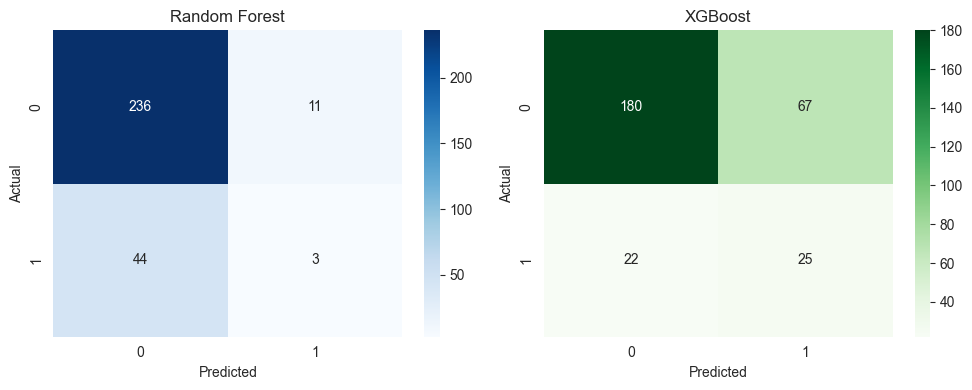

In [7]:
# CONFUSION MATRIX

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d',
            cmap='Blues', ax=axes[0])
axes[0].set_title("Random Forest")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d',
            cmap='Greens', ax=axes[1])
axes[1].set_title("XGBoost")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 8. ROC Curve

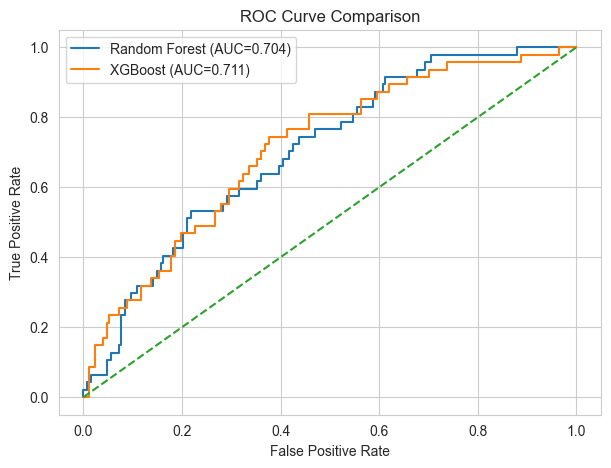

In [8]:
# ROC CURVE

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

rf_auc = roc_auc_score(y_test, rf_prob)
xgb_auc = roc_auc_score(y_test, xgb_prob)

plt.figure(figsize=(7, 5))

plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_auc:.3f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC={xgb_auc:.3f})")

plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

## 9. Precision-Recall Curve

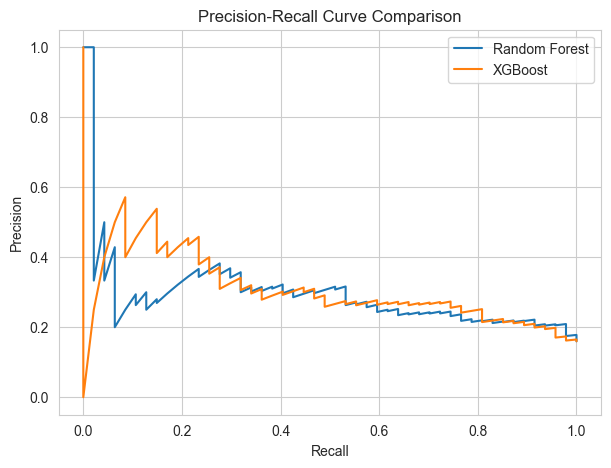

In [9]:
# PRECISION-RECALL CURVE

rf_prec, rf_rec, _ = precision_recall_curve(y_test, rf_prob)
xgb_prec, xgb_rec, _ = precision_recall_curve(y_test, xgb_prob)

plt.figure(figsize=(7, 5))

plt.plot(rf_rec, rf_prec, label="Random Forest")
plt.plot(xgb_rec, xgb_prec, label="XGBoost")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()

plt.show()

## 10. Final Comparison Summary

This study compared Random Forest and XGBoost models for predicting employee attrition.

- XGBoost achieved higher Recall and F1-score, indicating better performance in detecting employees likely to leave.
- Random Forest demonstrated stable Accuracy but struggled with minority class prediction.
- ROC-AUC results show that XGBoost has superior discrimination ability.
- Precision-Recall analysis further confirms XGBoost’s strength in handling imbalanced datasets.

### Final Conclusion:
XGBoost is the preferred model for this task due to its superior performance in identifying attrition cases and handling class imbalance effectively.